In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore") #Used to ignore warnings in output

In [2]:
df = pd.read_csv("Airbnb_datanew.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,19-10-2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,21-05-2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,05-07-2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,19-11-2018,0.10,1,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [4]:
df['neighbourhood_group'].unique()

<StringArray>
['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx']
Length: 5, dtype: str

In [5]:
df['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [6]:
df['neighbourhood'].unique() #Total unique Values present inside data

<StringArray>
[        'Kensington',            'Midtown',             'Harlem',
       'Clinton Hill',        'East Harlem',        'Murray Hill',
 'Bedford-Stuyvesant',     'Hell's Kitchen',    'Upper West Side',
          'Chinatown',
 ...
     'Fort Wadsworth',           'Rosebank',          'Unionport',
         'Mill Basin',      'Arden Heights',        'Bull's Head',
           'New Dorp',          'Rossville',       'Breezy Point',
        'Willowbrook']
Length: 221, dtype: str

In [7]:
df['neighbourhood'].value_counts()

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Richmondtown             1
Fort Wadsworth           1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64

In [8]:
df['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

# Check Null Values

In [9]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [10]:
# 1. drop them
# 2. Fill them -- any specifiv value
#              -- mean, median or mode  
# 3. drop the whole column instead

In [11]:
df = df.drop(columns= ['last_review'])

In [12]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [13]:
df['name'] = df['name'].fillna("Unknown")
df['host_name'] = df['host_name'].fillna("Unknown")
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [14]:
df.sample(20)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
13716,10297582,Sunny and huge room in Astoria!,52973925,Alexis,Queens,Astoria,40.75619,-73.91881,Private room,66,1,0,NaN,1,0
48761,36420855,1900s 1 Bed Rockaway Beach Bungalow-ByMTA&Beach,271885652,Elizabeth,Queens,Rockaway Beach,40.58893,-73.81347,Entire home/apt,89,1,0,NaN,4,175
30510,23612284,"Spacious, sunny duplex in Fort Greene, Brooklyn",2485076,Jacob,Brooklyn,Fort Greene,40.69466,-73.97151,Entire home/apt,148,3,20,1.27,1,0
45558,34833931,2BR LUXARY DUPLEX LOFT Downtown Brooklyn (4+ D...,48194192,Allen,Brooklyn,Clinton Hill,40.69526,-73.96321,Entire home/apt,395,4,1,1.00,4,22
43648,33780071,Designer Madison Ave Studio with Brand New Kit...,55782090,Chris,Manhattan,Upper East Side,40.78582,-73.95546,Entire home/apt,145,31,1,0.77,2,304
16379,13164770,Sunny Bedroom in Beautiful Apartment in Bushwick,22851099,Elena,Brooklyn,Bushwick,40.69074,-73.91705,Private room,40,1,0,NaN,1,0
32607,25590224,Private furnished room near Columbia University,673215,Jessica Rose,Manhattan,Harlem,40.82441,-73.95327,Private room,100,3,1,0.10,2,263
20576,16360727,"Cozy Apartment in Brooklyn, NY",106193743,Clifton,Brooklyn,Crown Heights,40.67816,-73.95112,Entire home/apt,100,7,0,NaN,1,0
47801,35932913,Huge bedroom in Morningside Heights townhouse,73964015,Austin,Manhattan,Harlem,40.80494,-73.95463,Private room,150,1,0,NaN,1,8
2901,1657110,Luxury & Charm. Steps from Christopher Park!,8315861,Jonathan,Manhattan,West Village,40.73433,-74.00360,Entire home/apt,195,5,52,0.74,1,0


In [15]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [16]:
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

# nunique - Gives no. of unique values

---
Q1. How many unique neighbourhoods?

---
Q2. How many Unique neighbourhood_groups?

---
Q3. How many unique hosts?

---
Q4. How many unique properties?

---
Q5. How many unique Airbnb names?

In [21]:
df['neighbourhood'].nunique()

221

In [22]:
df['neighbourhood_group'].nunique()

5

In [23]:
df['host_id'].nunique()

37457

In [24]:
df['id'].nunique()

48895

In [25]:
df['name'].nunique()

47897

# idxmax or Mode - Find the most frequent value.

---
Q6. Find out which type of room most airbnb's have

---

In [36]:
import statistics as stats
print(stats.mode(df['room_type']),"\n")

print(df['room_type'].mode(),'\n')

print(df['room_type'].value_counts().idxmax())

Entire home/apt 

0    Entire home/apt
Name: room_type, dtype: str 

Entire home/apt


---
Analyse Price Column --

1. Mean
2. Median
3. Outliers
---

In [39]:
mean = df['price'].mean()
print("Mean is : ", mean)

median =  df['price'].median()
print("Median is : ", median)

Mean is :  152.7206871868289
Median is :  106.0


In [40]:
# We use boxplot to find the outliers
# Skewness - Most data posts will be on one side.

df['price'].skew()

np.float64(19.118938995046033)

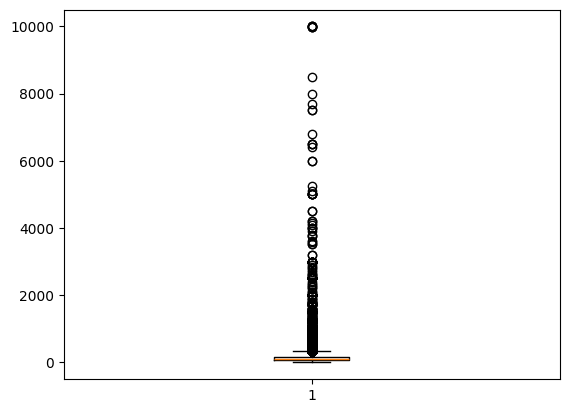

In [41]:
#checking outliers

plt.boxplot(df['price'])
plt.show()

In [53]:
# remove outliers using IQR method.

q1 = np.percentile(df['price'],25)
q3 = np.percentile(df['price'],75)

iqr = q3 - q1

ul = q3 + 1.5*iqr
ll = q1 - 1.5*iqr

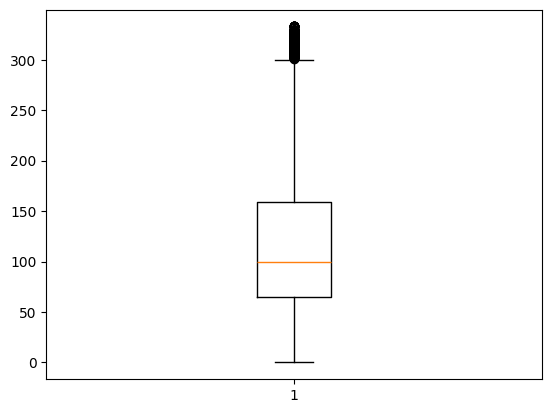

In [58]:
df1 = df[(df['price']>ll)&(df['price']<ul)]
plt.boxplot(df1['price'])
plt.show()

In [54]:
q1 = df['price'].quantile(.25)
q3 = df['price'].quantile(.75)

iqr = q3 - q1

ul = q3 + 1.5*iqr
ll = q1 - 1.5*iqr

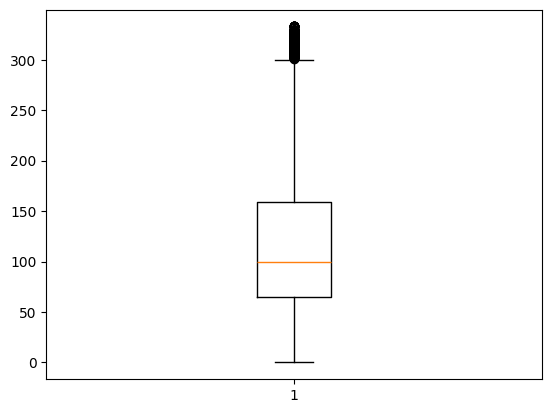

In [59]:
df = df[(df['price']<ul)&(df['price']>ll)]
plt.boxplot(df['price'])
plt.show()

<Axes: ylabel='price'>

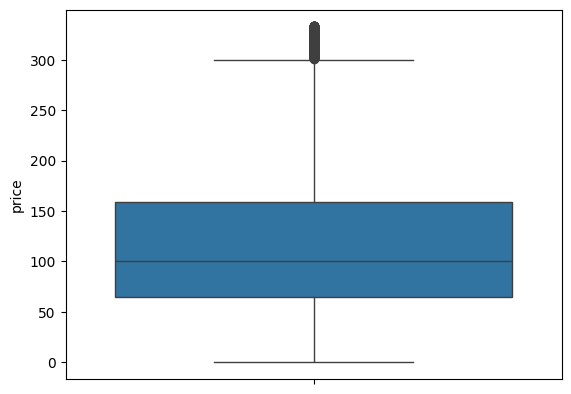

In [63]:
sns.boxplot(data = df['price'])

---
### Which airbnb room type charges the highest price?

---

In [73]:
df1 = df.groupby('room_type')['price'].mean()
pd.DataFrame(df1).idxmax()

price    Entire home/apt
dtype: str

In [76]:
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

---

### Find Average price in all the neighbourhood groups for the airbnbs

---

In [81]:
df2 = df.groupby('neighbourhood_group')['price'].mean()
pd.DataFrame(df2)

,price
neighbourhood_group,
Bronx,77.365421
Brooklyn,105.699614
Manhattan,145.904620
Queens,88.904437
Staten Island,89.235616


---
### Create a chart from where you can tell which neighbourhood is the busiest and which is the least

---

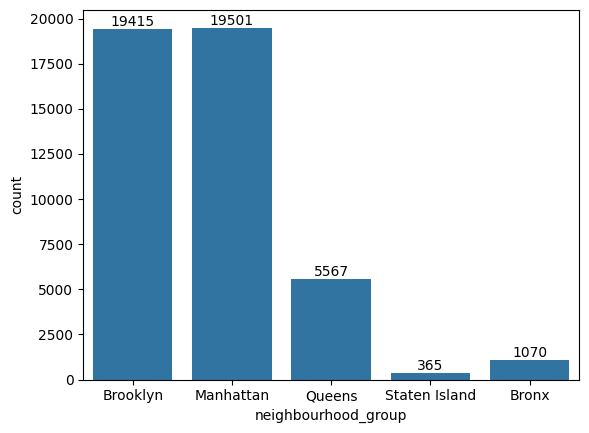

In [91]:
chart = sns.countplot(data = df, x='neighbourhood_group')
chart.bar_label(chart.containers[0])  #Shows exact values of bars
plt.show()